# 02 — KPI Framework & EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

PCOL = {'JioMart':'#E8441A', 'Blinkit':'#FDD835', 'Swiggy Instamart':'#FC8019'}

df = pd.read_csv('../data/cleaned_data.csv')
print(df.shape)


(100000, 17)


## KPI Scorecard

In [2]:
kpis = {
    'Total Orders'       : len(df),
    'Avg Delivery (min)' : round(df['Delivery Time (Minutes)'].mean(), 1),
    'Delay Rate %'       : round(df['Delay_Flag'].mean()*100, 1),
    'On-Time Rate %'     : round((1 - df['Delay_Flag'].mean())*100, 1),
    'Avg Rating'         : round(df['Service Rating'].mean(), 2),
    'Positive Feedback %': round((df['Service Rating'] >= 4).mean()*100, 1),
    'Negative Feedback %': round((df['Service Rating'] <= 2).mean()*100, 1),
    'Total Revenue INR'  : df['Order Value (INR)'].sum(),
    'Avg Order Value'    : round(df['Order Value (INR)'].mean(), 2),
    'Refund Rate %'      : round(df['Refund_Flag'].mean()*100, 1),
}

for k, v in kpis.items():
    print(f"  {k:<25} {v:>12}")


  Total Orders                    100000
  Avg Delivery (min)                29.5
  Delay Rate %                      13.7
  On-Time Rate %                    86.3
  Avg Rating                        3.24
  Positive Feedback %               46.5
  Negative Feedback %               45.8
  Total Revenue INR             59099440
  Avg Order Value                 590.99
  Refund Rate %                     45.8


## Platform Benchmarking

In [3]:
plat = df.groupby('Platform').agg(
    Orders     = ('Order ID', 'count'),
    Avg_Del    = ('Delivery Time (Minutes)', 'mean'),
    Avg_Rating = ('Service Rating', 'mean'),
    Delay_Pct  = ('Delay_Flag', 'mean'),
    Refund_Pct = ('Refund_Flag', 'mean'),
    Revenue    = ('Order Value (INR)', 'sum')
).round(3)

plat['Delay_Pct']  = (plat['Delay_Pct']  * 100).round(1)
plat['Refund_Pct'] = (plat['Refund_Pct'] * 100).round(1)
print(plat)


                  Orders  Avg_Del  Avg_Rating  Delay_Pct  Refund_Pct   Revenue
Platform                                                                      
Blinkit            33424   29.475       3.234       13.4        45.9  19705084
JioMart            33127   29.634       3.245       13.8        45.8  19562372
Swiggy Instamart   33449   29.500       3.243       13.8        45.7  19831984


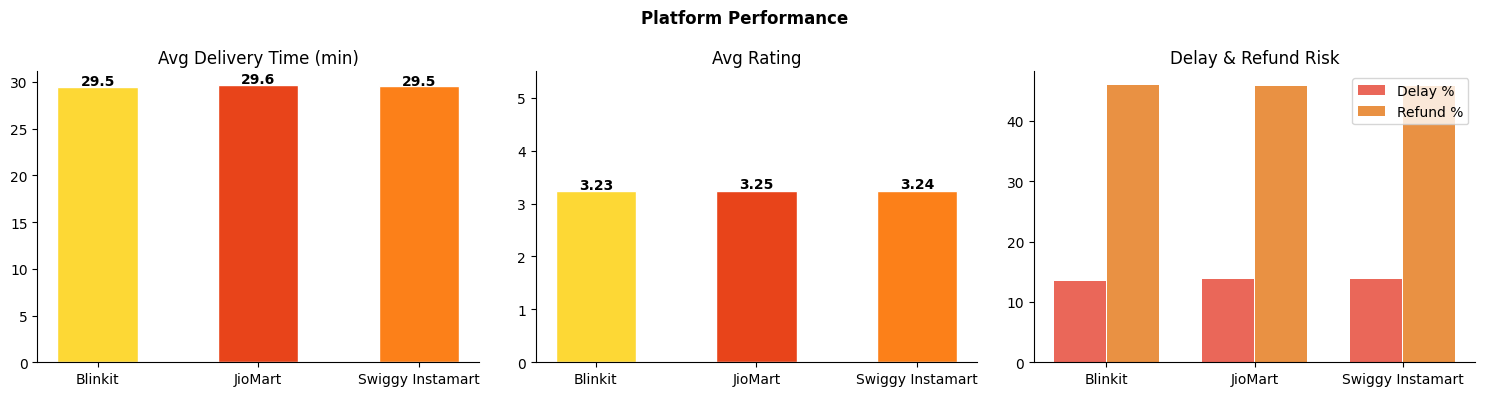

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Platform Performance', fontweight='bold')

platforms = plat.index.tolist()
cols      = [PCOL[p] for p in platforms]

axes[0].bar(platforms, plat['Avg_Del'],    color=cols, edgecolor='white', width=0.5)
axes[0].set_title('Avg Delivery Time (min)')
for i, v in enumerate(plat['Avg_Del']): axes[0].text(i, v+0.2, str(round(v,1)), ha='center', fontweight='bold')

axes[1].bar(platforms, plat['Avg_Rating'], color=cols, edgecolor='white', width=0.5)
axes[1].set_title('Avg Rating')
axes[1].set_ylim(0, 5.5)
for i, v in enumerate(plat['Avg_Rating']): axes[1].text(i, v+0.05, str(round(v,2)), ha='center', fontweight='bold')

x = np.arange(len(platforms))
axes[2].bar(x-0.18, plat['Delay_Pct'],  width=0.35, label='Delay %',  color='#E74C3C', alpha=0.85)
axes[2].bar(x+0.18, plat['Refund_Pct'], width=0.35, label='Refund %', color='#E67E22', alpha=0.85)
axes[2].set_title('Delay & Refund Risk')
axes[2].set_xticks(x)
axes[2].set_xticklabels(platforms)
axes[2].legend()

plt.tight_layout()
plt.savefig('../visuals/01_platform_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()


## Delivery Time Distribution

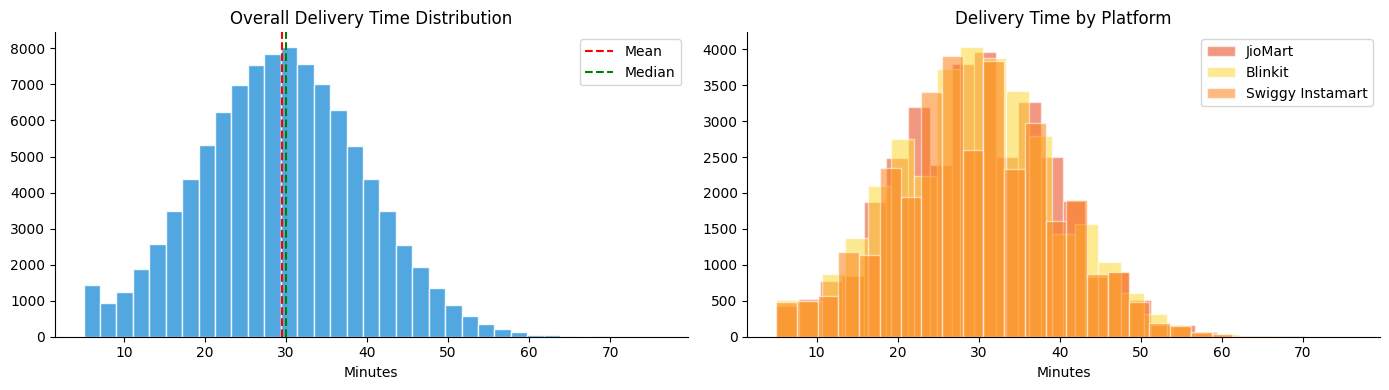

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Delivery Time (Minutes)'], bins=35, color='#3498DB', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Delivery Time (Minutes)'].mean(),   color='red',   linestyle='--', label='Mean')
axes[0].axvline(df['Delivery Time (Minutes)'].median(), color='green', linestyle='--', label='Median')
axes[0].set_title('Overall Delivery Time Distribution')
axes[0].set_xlabel('Minutes')
axes[0].legend()

for p in df['Platform'].unique():
    sub = df[df['Platform'] == p]['Delivery Time (Minutes)']
    axes[1].hist(sub, bins=25, alpha=0.55, label=p, color=PCOL[p], edgecolor='white')
axes[1].set_title('Delivery Time by Platform')
axes[1].set_xlabel('Minutes')
axes[1].legend()

plt.tight_layout()
plt.savefig('../visuals/02_delivery_dist.png', dpi=150, bbox_inches='tight')
plt.show()


## Delay & Refund Overview

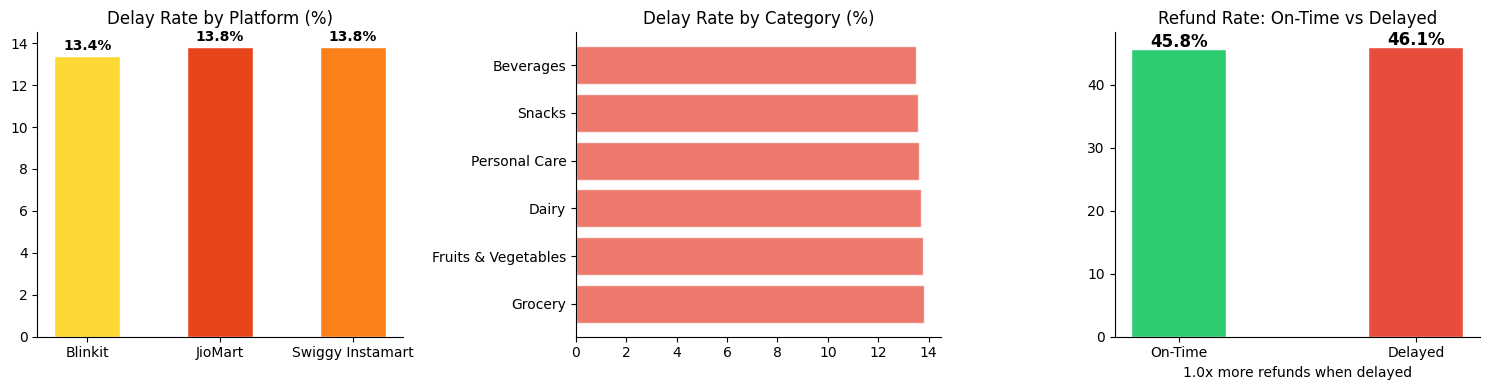

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# delay by platform
d_plat = df.groupby('Platform')['Delay_Flag'].mean() * 100
axes[0].bar(d_plat.index, d_plat.values, color=[PCOL[p] for p in d_plat.index], edgecolor='white', width=0.5)
axes[0].set_title('Delay Rate by Platform (%)')
for i, v in enumerate(d_plat.values): axes[0].text(i, v+0.3, str(round(v,1))+'%', ha='center', fontweight='bold')

# delay by category
d_cat = df.groupby('Product Category')['Delay_Flag'].mean().sort_values(ascending=False) * 100
axes[1].barh(d_cat.index, d_cat.values, color='#E74C3C', alpha=0.75, edgecolor='white')
axes[1].set_title('Delay Rate by Category (%)')

# refund vs delay
r_by_d = df.groupby('Delivery Delay')['Refund_Flag'].mean() * 100
axes[2].bar(['On-Time', 'Delayed'], r_by_d.values,
            color=['#2ECC71','#E74C3C'], edgecolor='white', width=0.4)
axes[2].set_title('Refund Rate: On-Time vs Delayed')
for i, v in enumerate(r_by_d.values): axes[2].text(i, v+0.3, str(round(v,1))+'%', ha='center', fontweight='bold', fontsize=12)
mult = round(r_by_d['Yes'] / r_by_d['No'], 1)
axes[2].set_xlabel(str(mult) + 'x more refunds when delayed')

plt.tight_layout()
plt.savefig('../visuals/03_delay_refund.png', dpi=150, bbox_inches='tight')
plt.show()


## Peak Hour Analysis

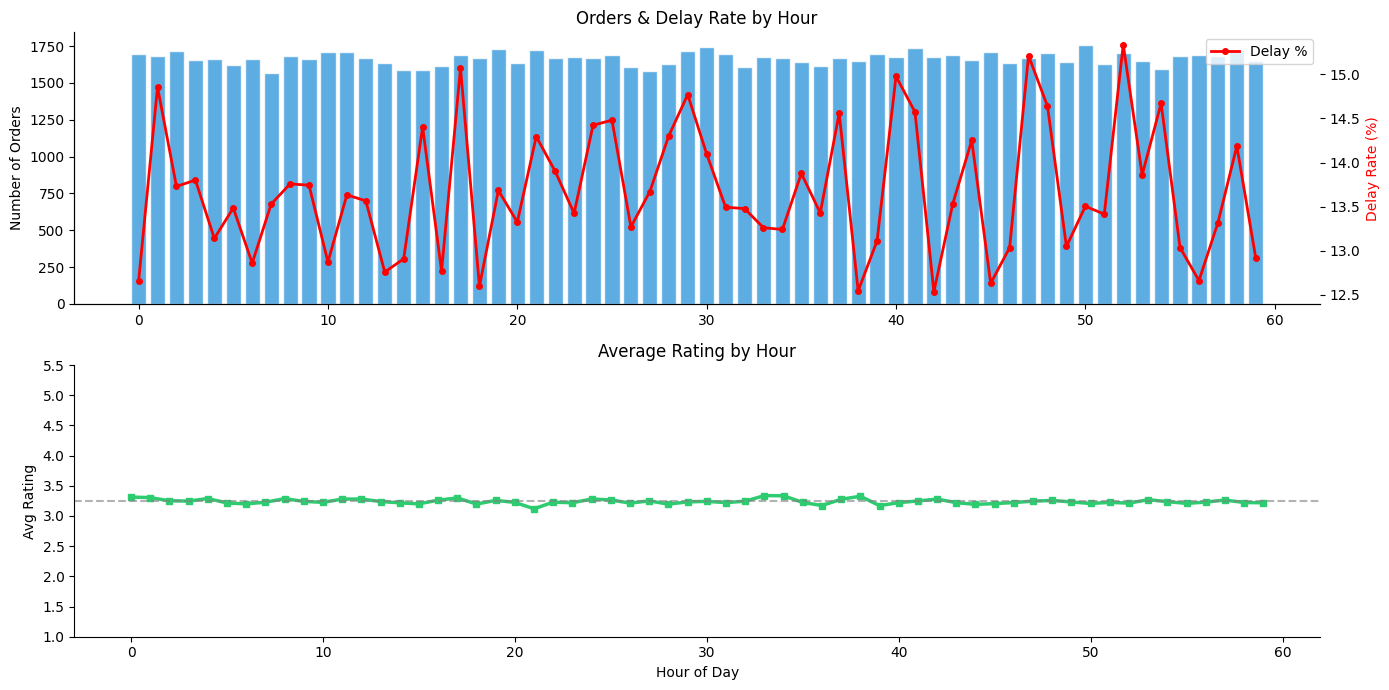

In [7]:
hourly = df.groupby('Hour').agg(
    Orders     = ('Order ID', 'count'),
    Delay_Rate = ('Delay_Flag', 'mean'),
    Avg_Rating = ('Service Rating', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].bar(hourly['Hour'], hourly['Orders'], color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].set_title('Orders & Delay Rate by Hour')
axes[0].set_ylabel('Number of Orders')

ax2 = axes[0].twinx()
ax2.plot(hourly['Hour'], hourly['Delay_Rate']*100, color='red', lw=2, marker='o', ms=4, label='Delay %')
ax2.set_ylabel('Delay Rate (%)', color='red')
ax2.legend(loc='upper right')

axes[1].plot(hourly['Hour'], hourly['Avg_Rating'], color='#2ECC71', lw=2.5, marker='s', ms=4)
axes[1].axhline(df['Service Rating'].mean(), color='gray', linestyle='--', alpha=0.6)
axes[1].set_title('Average Rating by Hour')
axes[1].set_ylabel('Avg Rating')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylim(1, 5.5)

plt.tight_layout()
plt.savefig('../visuals/04_peak_hours.png', dpi=150, bbox_inches='tight')
plt.show()
